In [1]:
import os
import sys
import plotly.graph_objects as go

import matplotlib.pyplot as plt

current_dir = os.getcwd()
project_root = current_dir[:current_dir.find("src") - 1]
sys.path.insert(0, project_root)
from src.models.filter_data.filter_data import *
from src.models.filter_data.feature_adder import *
from scipy.interpolate import make_interp_spline


In [2]:
l_min = 4
max_diff = 3
c_thresh = 0.9
bin_length = 20
temp_feature = "temp_sens"


In [5]:

csv_read_path = os.path.join(project_root, "data", "processed", "semi_processed.csv")
df = pd.read_csv(csv_read_path, encoding='utf-8')

necessary_features = ['name', 'code', "date", "hour", "generation", f"{temp_feature}", "load_level", "status"]
df.dropna(subset=necessary_features, inplace=True)

In [4]:
feature_adder = Feature_adder(df, temp_feature)
feature_adder = Feature_adder(df, temp_feature)
feature_adder.select_gas_plants()
feature_adder.filter1()
feature_adder.filter2(initial_label=1)
feature_adder.filter3(l_min=l_min, max_diff=max_diff, initial_label=2)
feature_adder.filter4(c_thresh=c_thresh, initial_label=3)
feature_adder.filter5(initial_label=4)

2025-11-03 17:04:12 - src.models.filter_data.feature_adder - INFO - 81.35% of rows have been chosen by filter1


TypeError: Feature_adder.filter2() got an unexpected keyword argument 'l_min'

In [6]:
filtered_df = df[df['is_good_peak'] >= 5]

In [7]:
def find_points_on_envelope(gens, sens_temps, bin_length=30, p=0.95):
    sorted_idx = np.argsort(sens_temps)
    sens_temps_sorted, gens_sorted = sens_temps[sorted_idx], gens[sorted_idx]

    n = len(sens_temps_sorted)
    points = []
    for start in range(0, n, bin_length):
        end = start + bin_length
        if end + bin_length > n:
            end = n
        x = sens_temps_sorted[start: end].mean()
        y = get_percentile(gens_sorted[start: end], p=p)
        points.append((x, y))

        if end == n:
            break

    X = np.array([a for a, b in points])
    y = np.array([b for a, b in points])

    return X, y

In [8]:
def work(i):
    features = ["name", "code", "generation", f"{temp_feature}", "is_good_peak"]
    df_modified = filtered_df[features].copy(deep=True)
    df_modified = df_modified[df_modified["is_good_peak"] >= 4]
    ds = Data_selector(df_modified)
    
    all_indices = []
    power_plants = df_modified[['name', 'code']].drop_duplicates()
    
    name, code = power_plants.iloc[i][["name", "code"]]
    print(name, code)
    
    one_unit_df = ds.filter_name_code(name, code)
    
    sens_temps = one_unit_df[temp_feature].values
    gens = one_unit_df['generation'].values
    
    X_95, y_95 = find_points_on_envelope(gens, sens_temps, bin_length=bin_length, p=1)
    X_85, y_85 = find_points_on_envelope(gens, sens_temps, bin_length=bin_length, p=0.75)
    
    
    curve1 = make_interp_spline(X_95, y_95, k=1)
    curve2 = make_interp_spline(X_85, y_85, k=1)
    
    # near_envelope_indices = select_envelope_neighbors_indices(X_95, y_95, X_85, y_85, one_unit_df, temp_feature, alpha=2, beta=5)
    # all_indices.extend(near_envelope_indices)
    
    # filtered_df.loc[all_indices, "is_good_peak"] = 5
    
    x_common = np.linspace(min(X_95),max(X_95), 500)
    
    y_curve1 = curve1(x_common)
    #y_curve2 = curve2(x_common)
    y_curve2 = y_curve1 - 3
    
    plt.figure(figsize=(8, 5))
    plt.plot(x_common, y_curve1, label='Curve 1', linewidth=2, color = "red")
    plt.plot(x_common, y_curve2, label='Curve 2', linewidth=2, color = "orange")
    plt.scatter(sens_temps, gens, color='blue', marker='o', label='Points', s=1)
    # plt.scatter(X_95, y_95, color='blue', marker='o', label='Points 1')
    # plt.scatter(X_85, y_85, color='red', marker='x', label='Points 2')
    
    plt.fill_between(x_common, y_curve1, y_curve2, color='gray', alpha=0.2)
    
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.legend()
    # plt.grid(True)
    plt.show()

In [9]:
i = 14

سبلان G16


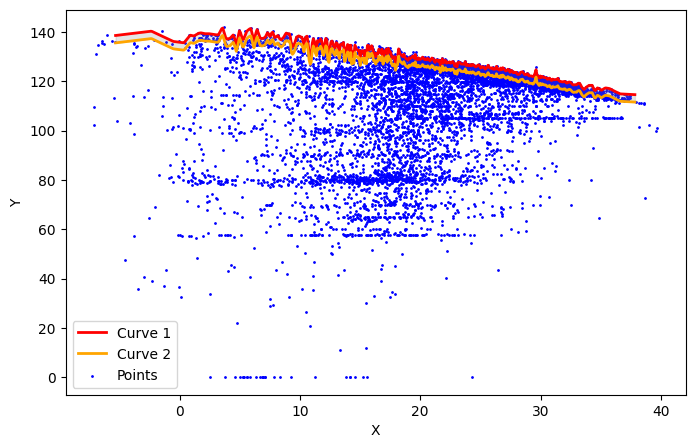

In [12]:
i +=1
work(i)

In [14]:
counts = filtered_df[['name', 'code']].value_counts()
print(counts)

name                   code
گیلان                  G11     28136
سیکل ترکیبی شیروان     G11     25825
شهدای پیروز - بهبهان   G11     24982
سبلان                  G11     21320
سیکل ترکیبی ارومیه     G11     18183
                               ...  
جنوب اصفهان - چهلستون  G16        10
                       G12        10
                       G15        10
                       G14        10
                       G13        10
Name: count, Length: 71, dtype: int64


(array([14., 13.,  1.,  1.,  2.,  7., 17.,  9.,  1.,  0.,  0.,  1.,  1.,
         0.,  0.,  1.,  0.,  1.,  1.,  1.]),
 array([1.00000e+01, 1.41630e+03, 2.82260e+03, 4.22890e+03, 5.63520e+03,
        7.04150e+03, 8.44780e+03, 9.85410e+03, 1.12604e+04, 1.26667e+04,
        1.40730e+04, 1.54793e+04, 1.68856e+04, 1.82919e+04, 1.96982e+04,
        2.11045e+04, 2.25108e+04, 2.39171e+04, 2.53234e+04, 2.67297e+04,
        2.81360e+04]),
 <BarContainer object of 20 artists>)

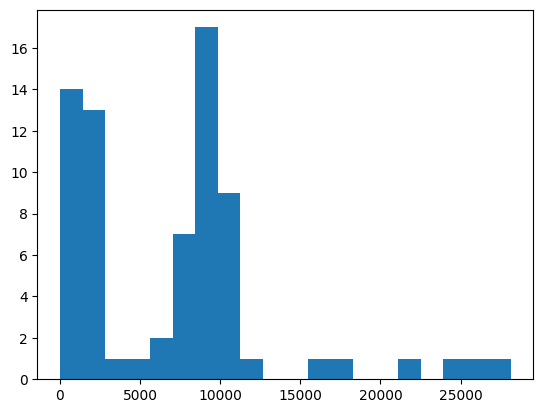

In [17]:
plt.hist(counts, bins=20)

In [19]:
counts[counts < 1000]

name                   code
قم                     G13     883
                       G12     883
شهدای پاکدشت - دماوند  G22     853
قم                     G14     695
جنوب اصفهان - چهلستون  G16      10
                       G12      10
                       G15      10
                       G14      10
                       G13      10
Name: count, dtype: int64